In [1]:
from chembl_webresource_client.new_client import new_client
import pandas as pd
import numpy as np

In [2]:
target=new_client.target

egfr_search=target.search("EGFR")

df_targets=pd.DataFrame(egfr_search)

print(df_targets[["target_chembl_id","pref_name","organism"]].head(10))

  target_chembl_id                                          pref_name  \
0       CHEMBL3608                   Epidermal growth factor receptor   
1    CHEMBL4523747                                        EGFR/PPP1CA   
2    CHEMBL5465557                                          CCN2-EGFR   
3        CHEMBL203                   Epidermal growth factor receptor   
4    CHEMBL4523680  Protein cereblon/Epidermal growth factor receptor   
5    CHEMBL2111431  Epidermal growth factor receptor and ErbB2 (HE...   
6    CHEMBL2363049                   Epidermal growth factor receptor   
7    CHEMBL4523998    von Hippel-Lindau disease tumor suppressor/EGFR   
8    CHEMBL4630723                          ErbB-2/ErbB-3 heterodimer   
9       CHEMBL1824            Receptor tyrosine-protein kinase erbB-2   

       organism  
0  Mus musculus  
1  Homo sapiens  
2  Homo sapiens  
3  Homo sapiens  
4  Homo sapiens  
5  Homo sapiens  
6  Homo sapiens  
7  Homo sapiens  
8  Homo sapiens  
9  Homo sapiens 

In [3]:
activity=new_client.activity

egfr_data=activity.filter(
    target_chembl_id="CHEMBL203",
    standard_type="IC50")

df=pd.DataFrame(egfr_data)

print(f"Total records fetched: {len(df)}")
print(df.columns.tolist())

Total records fetched: 25758
['action_type', 'activity_comment', 'activity_id', 'activity_properties', 'assay_chembl_id', 'assay_description', 'assay_type', 'assay_variant_accession', 'assay_variant_mutation', 'bao_endpoint', 'bao_format', 'bao_label', 'canonical_smiles', 'data_validity_comment', 'data_validity_description', 'document_chembl_id', 'document_journal', 'document_year', 'ligand_efficiency', 'molecule_chembl_id', 'molecule_pref_name', 'parent_molecule_chembl_id', 'pchembl_value', 'potential_duplicate', 'qudt_units', 'record_id', 'relation', 'src_id', 'standard_flag', 'standard_relation', 'standard_text_value', 'standard_type', 'standard_units', 'standard_upper_value', 'standard_value', 'target_chembl_id', 'target_organism', 'target_pref_name', 'target_tax_id', 'text_value', 'toid', 'type', 'units', 'uo_units', 'upper_value', 'value']


In [4]:
df=df[[
    "molecule_chembl_id",
    "canonical_smiles",
    "standard_value",
    "standard_units"]]

print(f"Shape : {df.shape}")
print(df.head())

Shape : (25758, 4)
  molecule_chembl_id                                   canonical_smiles  \
0        CHEMBL68920  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...   
1        CHEMBL68920  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...   
2        CHEMBL68920  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...   
3        CHEMBL69960  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...   
4        CHEMBL69960  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...   

  standard_value standard_units  
0           41.0             nM  
1          300.0             nM  
2         7820.0             nM  
3          170.0             nM  
4           40.0             nM  


In [7]:
df=df.dropna(subset=["canonical_smiles", "standard_value"])

df=df[df["standard_units"]=="nM"]

df["IC50_nM"]=pd.to_numeric(df["standard_value"], errors="coerce")

df=df.dropna(subset=["IC50_nM"])

df=df.drop_duplicates(subset="canonical_smiles")

print(f"Cleaned compounds: {len(df)}")
print(df.head())

Cleaned compounds: 13286
  molecule_chembl_id                                   canonical_smiles  \
0        CHEMBL68920  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...   
3        CHEMBL69960  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...   
6       CHEMBL137635        CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12   
7       CHEMBL306988             CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1   
8        CHEMBL66879                             O=C(O)/C=C/c1ccc(O)cc1   

  standard_value standard_units    IC50_nm    IC50_nM  
0           41.0             nM       41.0       41.0  
3          170.0             nM      170.0      170.0  
6         9300.0             nM     9300.0     9300.0  
7       500000.0             nM   500000.0   500000.0  
8      3000000.0             nM  3000000.0  3000000.0  


In [8]:
df["pIC50"]=-np.log10(df["IC50_nM"]* 1e-9)

df=df[(df["pIC50"]>=3) & (df["pIC50"]<=12)]

print(f"Final compounds: {len(df)}")
print(df[["molecule_chembl_id","IC50_nM","pIC50"]].head(10))

Final compounds: 13258
   molecule_chembl_id   IC50_nM     pIC50
0         CHEMBL68920      41.0  7.387216
3         CHEMBL69960     170.0  6.769551
6        CHEMBL137635    9300.0  5.031517
7        CHEMBL306988  500000.0  3.301030
9         CHEMBL77085   96000.0  4.017729
10       CHEMBL443268    5310.0  5.274905
11        CHEMBL76979  264000.0  3.578396
12        CHEMBL76589     125.0  6.903090
14       CHEMBL420385  625000.0  3.204120
15        CHEMBL76904   35000.0  4.455932


In [9]:
df.to_csv("EGFR_chembl_raw.csv",index=False)
print("saved!")

saved!


In [10]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors, Descriptors
import pandas as pd
import numpy as np

#loaded saved data
df=pd.read_csv("EGFR_chembl_raw.csv")
print(f"Loaded: {len(df)}")

Loaded: 13258


In [12]:
# calculate descriptors for each compound

rows=[]
failed=[]

for idx, row in df.iterrows():
    smi=row["canonical_smiles"]
    mol=Chem.MolFromSmiles(smi)

    if mol is None:
        failed+=1
        continue

    rows.append({
        "Chembl_id":row["molecule_chembl_id"],
        "SMILES":smi,
        "pIC50":row["pIC50"],

       #Physicochemical
        "MW":Descriptors.MolWt(mol),
        "LogP":Descriptors.MolLogP(mol),
        "HBD":rdMolDescriptors.CalcNumHBD(mol),
        "HBA":rdMolDescriptors.CalcNumHBA(mol),
        "TPSA":Descriptors.TPSA(mol),

       # Topologicall
        "RotBonds":rdMolDescriptors.CalcNumRotatableBonds(mol),
        "ArRings":rdMolDescriptors.CalcNumAromaticRings(mol),
        "Rings":rdMolDescriptors.CalcNumRings(mol),
        "HeavyAtoms":mol.GetNumHeavyAtoms(),})

df_desc=pd.DataFrame(rows)

print(f"Success : {len(df_desc)}")
print(f"Failed : {failed}")
print()
print(df_desc.head())

Success : 13258
Failed : []

      Chembl_id                                             SMILES     pIC50  \
0   CHEMBL68920  Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...  7.387216   
1   CHEMBL69960  Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...  6.769551   
2  CHEMBL137635        CN(c1ccccc1)c1ncnc2ccc(N/N=N/Cc3ccccn3)cc12  5.031517   
3  CHEMBL306988             CC(=C(C#N)C#N)c1ccc(NC(=O)CCC(=O)O)cc1  3.301030   
4   CHEMBL77085                 N#CC(C#N)=Cc1cc(O)ccc1[N+](=O)[O-]  4.017729   

        MW     LogP  HBD  HBA    TPSA  RotBonds  ArRings  Rings  HeavyAtoms  
0  383.814  4.45034    3    4   82.70         3        3      4          27  
1  482.903  3.61432    3    6  112.24         4        3      5          34  
2  369.432  4.77200    1    6   78.66         6        4      4          28  
3  283.287  2.31056    2    4  113.98         5        1      1          21  
4  215.168  1.73096    1    5  110.95         2        1      1          16  


In [13]:
df_desc.to_csv("EGFR_descriptors.csv",index=False)
print("saved!")

saved!


In [14]:
import matplotlib.pyplot as plt

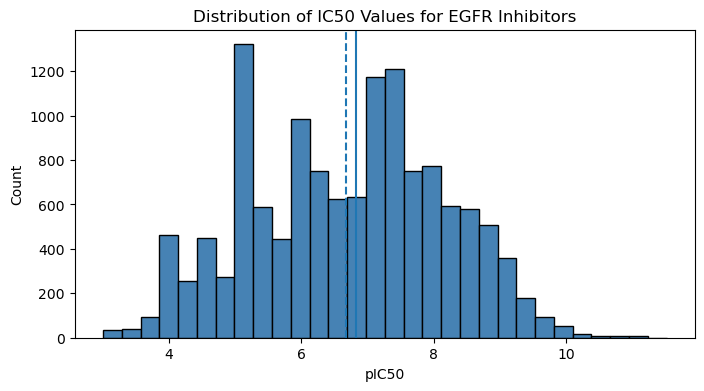

saved!


In [19]:
# Check pIC50 distribution 

plt.figure(figsize=(8, 4))
plt.hist(df_desc["pIC50"], bins=30, color="steelblue", edgecolor="black")
plt.xlabel("pIC50")
plt.ylabel("Count")
plt.title("Distribution of IC50 Values for EGFR Inhibitors")
plt.axvline(x=df_desc["pIC50"].mean(),  linestyle='--')
plt.axvline(x=df_desc["pIC50"].median(), linestyle='-')
plt.savefig("pIC50_distribution_for_egfr.png")
plt.show()
print("saved!")

In [20]:
print(df_desc[[
    "MW","LogP","HBD","HBA","TPSA","RotBonds","ArRings","pIC50"]].describe().round(2))

             MW      LogP       HBD       HBA      TPSA  RotBonds   ArRings  \
count  13258.00  13258.00  13258.00  13258.00  13258.00  13258.00  13258.00   
mean     480.67      4.63      2.14      7.00     94.96      6.86      3.57   
std      123.16      1.49      1.20      2.28     30.77      3.21      0.99   
min      110.11     -5.99      0.00      0.00      0.00      0.00      0.00   
25%      400.39      3.69      1.00      6.00     76.13      5.00      3.00   
50%      479.48      4.57      2.00      7.00     94.60      7.00      4.00   
75%      552.46      5.54      3.00      8.00    110.73      9.00      4.00   
max     1425.80     13.03     17.00     21.00    530.87     36.00      9.00   

          pIC50  
count  13258.00  
mean       6.68  
std        1.46  
min        3.00  
25%        5.45  
50%        6.82  
75%        7.77  
max       11.52  
